In [1]:
# make sure you installed the mnist1d package

%load_ext autoreload
%autoreload 2
import torch
import import_ipynb
from a02_functions import SimpleCNN, SimpleMLP, train_model
from a02_helper import (
    plot_templates,
    get_raw_data,
    count_model_params,
    shuffle_pixels,
    plot_example,
    nextplot,
)

# Task 2: MNIST-1D
### Dataset

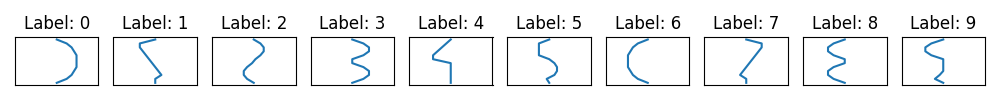

In [2]:
# Those are the templates that the examples in the dataset are based on.
nextplot()
plot_templates()

In [3]:
data = get_raw_data()

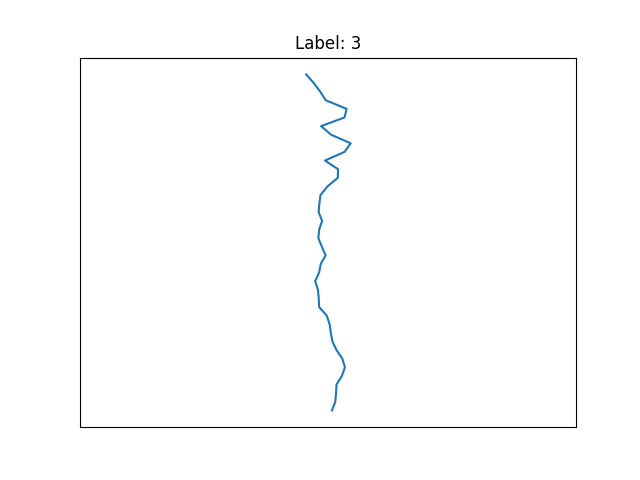

In [4]:
idx = 8
x, y, t = data["x"][idx], data["y"][idx], data["t"]
nextplot()
plot_example(x, y, t)

### Model

Verify your model's implementation by running the following test cases.

In [5]:
# 2b
torch.manual_seed(0)
cnn = SimpleCNN()
x_unbatched = torch.ones(40)
x_batched = x_unbatched.view(1, -1)
with torch.no_grad():  # these should give no error
    y_batched = cnn(x_batched)
    y_unbatched = cnn(x_unbatched)

x_batched, x_unbatched  # these are the inputs being used

(tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
          1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
          1., 1., 1., 1.]]),
 tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1., 1., 1.]))

Initialize your model and verify the total number of parameters computed by
hand.

In [6]:
# 2c
torch.manual_seed(0)
cnn = SimpleCNN(channels=5, kernel_size=3, stride=2, padding=1, linear_in=5)
print(cnn)
print(f"No. of parameters: {count_model_params(cnn)}")

SimpleCNN(
  (conv1): Conv1d(1, 5, kernel_size=(3,), stride=(2,), padding=(1,))
  (conv2): Conv1d(5, 5, kernel_size=(3,), stride=(2,), padding=(1,))
  (conv3): Conv1d(5, 5, kernel_size=(3,), stride=(2,), padding=(1,))
  (conv4): Conv1d(5, 5, kernel_size=(3,), stride=(2,), padding=(1,))
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (linear): Linear(in_features=5, out_features=10, bias=True)
)
No. of parameters: 320


### Training

Train your model.

In [14]:
torch.manual_seed(0)
# default parameters
cnn = SimpleCNN()  
results = train_model(data, cnn)

epoch 0, dt 0.15s, train_loss 1.618e+00, val_loss 1.588e+00, train_acc 37.9, val_acc 35.8
epoch 10, dt 1.33s, train_loss 8.444e-01, val_loss 7.647e-01, train_acc 77.8, val_acc 73.1
epoch 20, dt 1.30s, train_loss 1.535e-01, val_loss 4.929e-01, train_acc 94.5, val_acc 83.9
epoch 30, dt 1.25s, train_loss 2.571e-01, val_loss 5.409e-01, train_acc 96.4, val_acc 87.8
epoch 40, dt 1.25s, train_loss 2.597e-02, val_loss 5.567e-01, train_acc 98.3, val_acc 87.8
epoch 50, dt 1.25s, train_loss 1.436e-01, val_loss 7.377e-01, train_acc 96.8, val_acc 84.9
epoch 60, dt 1.50s, train_loss 5.995e-03, val_loss 7.076e-01, train_acc 99.3, val_acc 89.9
epoch 70, dt 1.47s, train_loss 6.791e-02, val_loss 8.431e-01, train_acc 97.3, val_acc 86.5
epoch 80, dt 1.36s, train_loss 2.734e-03, val_loss 6.274e-01, train_acc 99.9, val_acc 88.9
epoch 90, dt 1.40s, train_loss 3.325e-04, val_loss 6.678e-01, train_acc 100.0, val_acc 90.2
Final result: train_loss 1.653e-04, val_loss 6.678e-01, test_loss 6.433e-01, train_acc 100

### Simple Feedforward Neural Network

Compare the results of the CNN and FNN models (after your conjecture!).

In [18]:
# 2e)
torch.manual_seed(0)
fnn = SimpleMLP()
print(f"No. of parameters: {count_model_params(fnn)}")

No. of parameters: 78858


In [19]:
results = train_model(data, fnn)

epoch 0, dt 0.06s, train_loss 1.603e+00, val_loss 1.654e+00, train_acc 43.3, val_acc 36.9
epoch 10, dt 0.58s, train_loss 5.059e-01, val_loss 1.706e+00, train_acc 82.6, val_acc 55.8
epoch 20, dt 0.65s, train_loss 5.885e-01, val_loss 2.338e+00, train_acc 91.0, val_acc 59.4
epoch 30, dt 0.68s, train_loss 2.701e-01, val_loss 2.564e+00, train_acc 96.8, val_acc 59.6
epoch 40, dt 0.70s, train_loss 6.318e-02, val_loss 3.273e+00, train_acc 96.7, val_acc 60.2
epoch 50, dt 0.69s, train_loss 7.237e-02, val_loss 4.204e+00, train_acc 96.9, val_acc 60.1
epoch 60, dt 0.71s, train_loss 1.503e-01, val_loss 4.405e+00, train_acc 97.5, val_acc 60.0
epoch 70, dt 0.72s, train_loss 2.044e-01, val_loss 4.809e+00, train_acc 98.9, val_acc 62.8
epoch 80, dt 0.80s, train_loss 1.448e-01, val_loss 5.218e+00, train_acc 97.6, val_acc 61.8
epoch 90, dt 0.80s, train_loss 2.051e-05, val_loss 5.083e+00, train_acc 99.8, val_acc 65.0
Final result: train_loss 5.866e-02, val_loss 5.083e+00, test_loss 5.203e+00, train_acc 99.8

### Shuffled Dataset

Shuffle the dataset along the spatial dimension.

In [24]:
shuffled_dataset = shuffle_pixels(data)

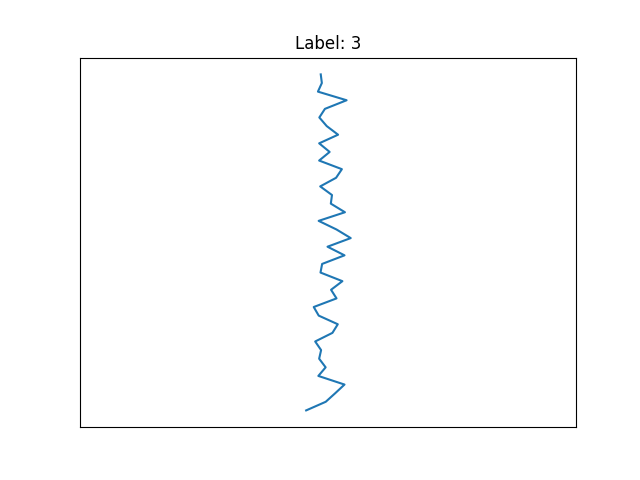

In [31]:
idx = 8
x, y, t = shuffled_dataset["x"][idx], shuffled_dataset["y"][idx], shuffled_dataset["t"]
nextplot()
plot_example(x, y, t)

In [32]:
torch.manual_seed(0)
cnn = SimpleCNN()
results = train_model(shuffled_dataset, cnn)

epoch 0, dt 0.13s, train_loss 1.577e+00, val_loss 1.630e+00, train_acc 37.8, val_acc 38.0
epoch 10, dt 1.23s, train_loss 8.527e-01, val_loss 1.198e+00, train_acc 65.1, val_acc 56.8
epoch 20, dt 1.24s, train_loss 6.037e-01, val_loss 1.388e+00, train_acc 74.8, val_acc 56.6
epoch 30, dt 1.31s, train_loss 3.661e-01, val_loss 1.683e+00, train_acc 78.6, val_acc 56.0
epoch 40, dt 1.37s, train_loss 3.790e-01, val_loss 1.712e+00, train_acc 81.7, val_acc 55.1
epoch 50, dt 1.48s, train_loss 3.691e-01, val_loss 2.186e+00, train_acc 83.8, val_acc 55.0
epoch 60, dt 1.45s, train_loss 2.575e-01, val_loss 2.211e+00, train_acc 86.1, val_acc 57.0
epoch 70, dt 1.47s, train_loss 3.407e-01, val_loss 2.468e+00, train_acc 80.9, val_acc 56.8
epoch 80, dt 1.53s, train_loss 1.617e-01, val_loss 2.582e+00, train_acc 93.3, val_acc 59.1
epoch 90, dt 1.55s, train_loss 1.462e-01, val_loss 2.871e+00, train_acc 93.9, val_acc 60.6
Final result: train_loss 2.282e-01, val_loss 2.871e+00, test_loss 3.574e+00, train_acc 93.9

In [33]:
torch.manual_seed(0)
fnn = SimpleMLP()
results = train_model(shuffled_dataset, fnn)

epoch 0, dt 0.07s, train_loss 1.585e+00, val_loss 1.671e+00, train_acc 42.5, val_acc 35.6
epoch 10, dt 0.60s, train_loss 6.122e-01, val_loss 1.702e+00, train_acc 82.2, val_acc 54.1
epoch 20, dt 0.66s, train_loss 3.953e-01, val_loss 2.372e+00, train_acc 91.8, val_acc 58.9
epoch 30, dt 0.70s, train_loss 9.278e-02, val_loss 2.812e+00, train_acc 98.0, val_acc 60.1
epoch 40, dt 0.71s, train_loss 9.266e-02, val_loss 3.355e+00, train_acc 96.5, val_acc 60.6
epoch 50, dt 0.72s, train_loss 5.932e-02, val_loss 4.040e+00, train_acc 97.5, val_acc 60.8
epoch 60, dt 0.78s, train_loss 4.153e-01, val_loss 4.462e+00, train_acc 95.5, val_acc 62.0
epoch 70, dt 0.78s, train_loss 1.338e-01, val_loss 5.039e+00, train_acc 98.9, val_acc 60.6
epoch 80, dt 0.82s, train_loss 1.164e-01, val_loss 5.205e+00, train_acc 98.1, val_acc 61.0
epoch 90, dt 0.79s, train_loss 1.422e-01, val_loss 5.861e+00, train_acc 97.6, val_acc 59.9
Final result: train_loss 1.063e-02, val_loss 5.861e+00, test_loss 5.443e+00, train_acc 97.6